# 09 — Checkpoint Evaluation & Learning Curves

Evaluates each saved checkpoint to reconstruct learning curves for:
- **Symbolic PPO** (1-1)
- **Pixel PPO** (1-1)
- **Transfer Learning** (1-2)

Generates comparison plots for the report.

In [4]:
import os, sys
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')

import numpy as np
import matplotlib.pyplot as plt
from stable_baselines3 import PPO
from src.wrappers import make_symbolic_env
from src.wrappers.pixel_wrappers import make_pixel_env

In [5]:
def evaluate_checkpoint(model, env, n_episodes=10):
    """Evaluate a model on an env, return mean reward, flag rate, mean length."""
    rewards, flags, lengths = [], [], []
    for _ in range(n_episodes):
        obs = env.reset()
        obs = obs[0] if isinstance(obs, tuple) else obs
        done, total_reward, steps, flag = False, 0.0, 0, False
        while not done:
            action, _ = model.predict(obs, deterministic=True)
            result = env.step(int(action))
            if len(result) == 5:
                obs, reward, terminated, truncated, info = result
                done = terminated or truncated
            else:
                obs, reward, done, info = result
            total_reward += float(reward)
            steps += 1
            if isinstance(info, dict) and info.get('flag_get', False):
                flag = True
        rewards.append(total_reward)
        flags.append(flag)
        lengths.append(steps)
    return np.mean(rewards), np.mean(flags), np.mean(lengths)


def eval_checkpoints(checkpoint_paths, steps_list, env, label=''):
    """Evaluate a list of checkpoints and return arrays of metrics."""
    mean_rewards, flag_rates, mean_lengths = [], [], []
    for path, step in zip(checkpoint_paths, steps_list):
        print(f'  [{label}] Evaluating {os.path.basename(path)} ({step/1000:.0f}k steps)...')
        model = PPO.load(path)
        r, f, l = evaluate_checkpoint(model, env)
        mean_rewards.append(r)
        flag_rates.append(f)
        mean_lengths.append(l)
        print(f'    reward={r:.1f}, flag_rate={f:.0%}, length={l:.0f}')
    return np.array(mean_rewards), np.array(flag_rates), np.array(mean_lengths)

## Evaluate Symbolic PPO (1-1)

In [6]:
sym_env = make_symbolic_env(env_id='SuperMarioBros-1-1-v3', skip=4, n_stack=4, flatten=True)

sym_paths = [
    '../models/symbolic_ppo/model_50000',
    '../models/symbolic_ppo/model_100000',
    '../models/symbolic_ppo/model_150000',
    '../models/symbolic_ppo/model_200000',
    '../models/symbolic_ppo/model_250000',
    '../models/symbolic_ppo/final_model',
]
sym_steps = [50_000, 100_000, 150_000, 200_000, 250_000, 4_000_000]

sym_rewards, sym_flags, sym_lengths = eval_checkpoints(sym_paths, sym_steps, sym_env, label='Symbolic')
sym_env.close()

  [Symbolic] Evaluating model_50000 (50k steps)...


/home/contente/miniconda3/envs/mario_lucas/lib/python3.14/site-packages/stable_baselines3/common/on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(
/home/contente/miniconda3/envs/mario_lucas/lib/python3.14/site-packages/gym/utils/passive_env_checker.py:195: UserWarning: WARN: The result returned by `env.reset()` was not a tuple of the form `(obs, info)`, where `obs` is a observation and `info` is a dictionary containing additional information. Actual type: `<class 'numpy.ndarray'>`
  logger.warn(
/home/contente/miniconda3/envs/mario_lucas

    reward=314.7, flag_rate=100%, length=326
  [Symbolic] Evaluating model_100000 (100k steps)...
    reward=314.7, flag_rate=100%, length=326
  [Symbolic] Evaluating model_150000 (150k steps)...
    reward=314.1, flag_rate=100%, length=326
  [Symbolic] Evaluating model_200000 (200k steps)...
    reward=314.1, flag_rate=100%, length=326
  [Symbolic] Evaluating model_250000 (250k steps)...
    reward=315.2, flag_rate=100%, length=326
  [Symbolic] Evaluating final_model (4000k steps)...
    reward=315.2, flag_rate=100%, length=326


## Evaluate Pixel PPO (1-1)

In [7]:
pix_env = make_pixel_env(env_id='SuperMarioBros-1-1-v3', skip=4)

pix_paths = [
    '../models/pixel_ppo/model_50000',
    '../models/pixel_ppo/model_100000',
    '../models/pixel_ppo/model_150000',
    '../models/pixel_ppo/model_200000',
    '../models/pixel_ppo/model_250000',
    '../models/pixel_ppo/final_model',
]
pix_steps = [50_000, 100_000, 150_000, 200_000, 250_000, 4_000_000]

pix_rewards, pix_flags, pix_lengths = eval_checkpoints(pix_paths, pix_steps, pix_env, label='Pixel')
pix_env.close()

  [Pixel] Evaluating model_50000 (50k steps)...
    reward=314.6, flag_rate=100%, length=318
  [Pixel] Evaluating model_100000 (100k steps)...
    reward=314.6, flag_rate=100%, length=318
  [Pixel] Evaluating model_150000 (150k steps)...
    reward=314.6, flag_rate=100%, length=318
  [Pixel] Evaluating model_200000 (200k steps)...
    reward=314.6, flag_rate=100%, length=318
  [Pixel] Evaluating model_250000 (250k steps)...
    reward=314.9, flag_rate=100%, length=318
  [Pixel] Evaluating final_model (4000k steps)...
    reward=314.9, flag_rate=100%, length=318


## Learning Curves: Symbolic vs Pixel

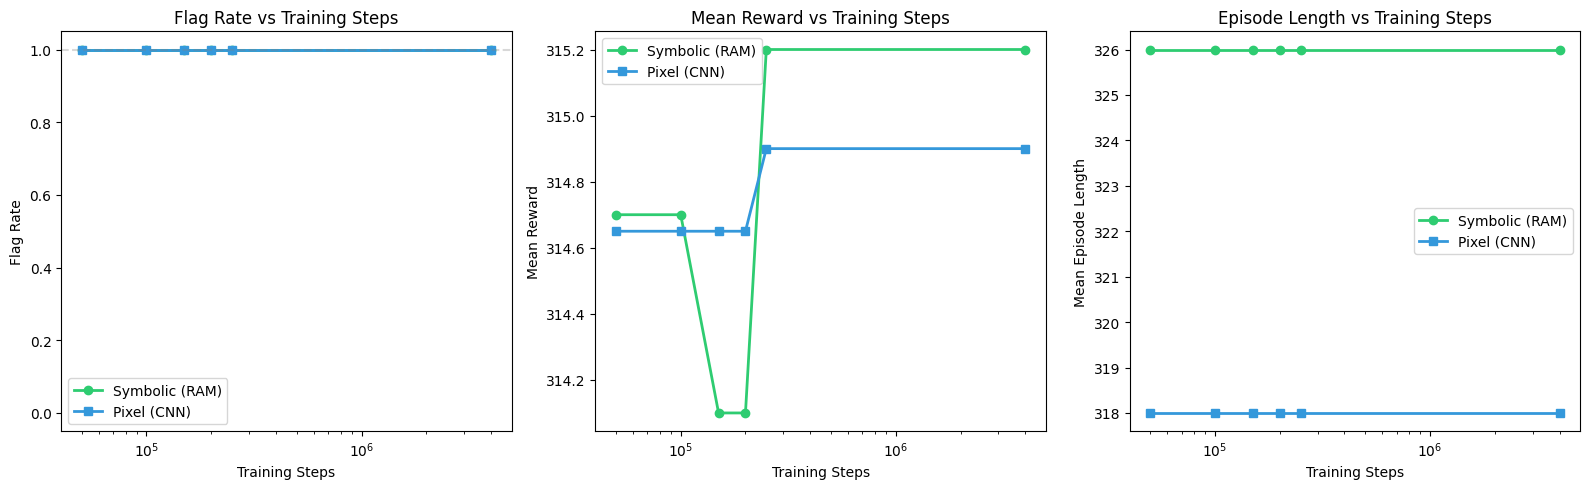

Saved to ../results/symbolic_vs_pixel_learning_curves.png


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Flag Rate
ax = axes[0]
ax.plot(sym_steps, sym_flags, 'o-', color='#2ecc71', label='Symbolic (RAM)', linewidth=2, markersize=6)
ax.plot(pix_steps, pix_flags, 's-', color='#3498db', label='Pixel (CNN)', linewidth=2, markersize=6)
ax.set_xlabel('Training Steps')
ax.set_ylabel('Flag Rate')
ax.set_title('Flag Rate vs Training Steps')
ax.legend()
ax.set_ylim(-0.05, 1.05)
ax.axhline(y=1.0, color='gray', linestyle='--', alpha=0.3)
ax.set_xscale('log')

# Mean Reward
ax = axes[1]
ax.plot(sym_steps, sym_rewards, 'o-', color='#2ecc71', label='Symbolic (RAM)', linewidth=2, markersize=6)
ax.plot(pix_steps, pix_rewards, 's-', color='#3498db', label='Pixel (CNN)', linewidth=2, markersize=6)
ax.set_xlabel('Training Steps')
ax.set_ylabel('Mean Reward')
ax.set_title('Mean Reward vs Training Steps')
ax.legend()
ax.set_xscale('log')

# Mean Episode Length
ax = axes[2]
ax.plot(sym_steps, sym_lengths, 'o-', color='#2ecc71', label='Symbolic (RAM)', linewidth=2, markersize=6)
ax.plot(pix_steps, pix_lengths, 's-', color='#3498db', label='Pixel (CNN)', linewidth=2, markersize=6)
ax.set_xlabel('Training Steps')
ax.set_ylabel('Mean Episode Length')
ax.set_title('Episode Length vs Training Steps')
ax.legend()
ax.set_xscale('log')

plt.tight_layout()
plt.savefig('../results/symbolic_vs_pixel_learning_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved to ../results/symbolic_vs_pixel_learning_curves.png')

## Summary Table

In [9]:
print(f'{"Method":<20} {"Steps":>10} {"Reward":>10} {"Flag%":>8} {"Length":>8}')
print('=' * 58)

for steps, r, f, l in zip(sym_steps, sym_rewards, sym_flags, sym_lengths):
    label = f'Symbolic {steps/1000:.0f}k' if steps < 1_000_000 else f'Symbolic {steps/1_000_000:.0f}M'
    print(f'{label:<20} {steps:>10,} {r:>10.1f} {f:>7.0%} {l:>8.0f}')

print('-' * 58)

for steps, r, f, l in zip(pix_steps, pix_rewards, pix_flags, pix_lengths):
    label = f'Pixel {steps/1000:.0f}k' if steps < 1_000_000 else f'Pixel {steps/1_000_000:.0f}M'
    print(f'{label:<20} {steps:>10,} {r:>10.1f} {f:>7.0%} {l:>8.0f}')

Method                    Steps     Reward    Flag%   Length
Symbolic 50k             50,000      314.7    100%      326
Symbolic 100k           100,000      314.7    100%      326
Symbolic 150k           150,000      314.1    100%      326
Symbolic 200k           200,000      314.1    100%      326
Symbolic 250k           250,000      315.2    100%      326
Symbolic 4M           4,000,000      315.2    100%      326
----------------------------------------------------------
Pixel 50k                50,000      314.6    100%      318
Pixel 100k              100,000      314.6    100%      318
Pixel 150k              150,000      314.6    100%      318
Pixel 200k              200,000      314.6    100%      318
Pixel 250k              250,000      314.9    100%      318
Pixel 4M              4,000,000      314.9    100%      318
